# Global vars and imports

In [1]:
# file_name = 'Mihail_Pletnyov_SHopen_Vals_3_lya_minor_dlya_fortepiano_Op_34_2'
# file_name = '01-utr-molitva'
# file_name = '02-zimnee-utro'
# file_name = '10-polka'
file_name = 'turkish-march-mozart-rondo-alla-turca'
# file_name = '15-italy-pesenka'
# file_name = 'Example_diploma'
# file_name = 'audio_2026-03-10_19-06-14'

path = f'sound_examples/{file_name}.mp3'

offset, duration = 0, 20
# sr = 44000

m_path = 'vec2vec_model/model_name v7.keras'
threshold = 0.3

In [2]:
%cd '/home/julia/Music/diploma/Rhythm_first_AMT'

/home/julia/Music/diploma/Rhythm_first_AMT


In [3]:
from modules.global_vars import *

/home/julia/Music/diploma/Rhythm_first_AMT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from IPython.display import Audio
import sys
import librosa
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from scipy.signal import find_peaks

# Rythm extraction

In [5]:
y_init, sr_init = librosa.load(path, offset=offset, duration=duration)
y = librosa.resample(y=y_init, orig_sr=sr_init, target_sr=SR)
Audio(y, rate=SR)

In [6]:
n_fft = N_FFT
hop_length = HOP_LENGTH
win_length = n_fft
window = 'hann'

D = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length,
                        win_length=win_length, window=window))

S = D ** 2

log_S = librosa.power_to_db(S, ref=1.0)

D_concat_with_0 = np.concat([np.zeros((D.shape[0], 1)), D, np.zeros((D.shape[0], 1))], axis=1)
diff_D = np.maximum(0, D_concat_with_0[:, 1:] - D_concat_with_0[:, :-1])
diff2_D = np.maximum(0, diff_D[:, :-1] - diff_D[:, 1:])
diff_D = diff_D[:, :-1]

In [7]:
def get_mode(np_arr, axis=None, keepdims=False):
    return stats.mode(np_arr, axis=axis, keepdims=keepdims).mode

In [8]:
tempo = librosa.feature.tempo(y=y, sr=SR, aggregate=get_mode, std_bpm=1,
                              hop_length=hop_length)
tempo

array([112.34714674])

In [9]:
from modules.rhythm_extract import get_offset_frames
onset_frames, beat_frames, oenv, mult_coeff = get_offset_frames(y, SR, hop_length=hop_length)

In [10]:
beat_times = librosa.frames_to_time(beat_frames, sr=SR, hop_length=hop_length, n_fft=N_FFT)
onset_times = librosa.frames_to_time(onset_frames, sr=SR, hop_length=hop_length, n_fft=N_FFT)

In [11]:
diff_beats = np.diff(beat_times)
diff_onsets = np.diff(onset_times)
ons_mean_part = stats.mode(diff_onsets).mode
beat_mean_part = stats.mode(diff_beats).mode

tempo2 = tempo * beat_mean_part / ons_mean_part
tempo_dynamic_2 = librosa.feature.tempo(y=y, sr=SR, start_bpm=tempo2, aggregate=None, std_bpm=1, hop_length=hop_length)

_, mini_beat_times = librosa.beat.beat_track(y=y, sr=SR, hop_length=hop_length, bpm=tempo_dynamic_2,
                                        units='time', trim=False)

mini_beat_frames = librosa.time_to_frames(mini_beat_times, sr=SR, hop_length=hop_length)

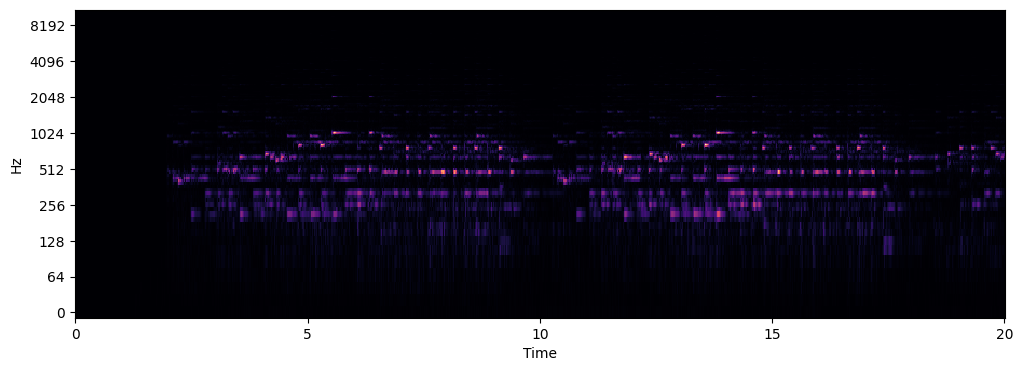

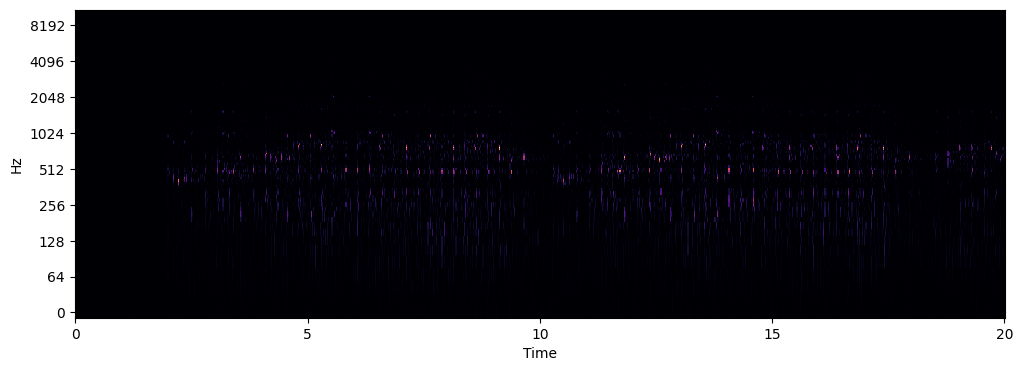

In [12]:
plt.figure(figsize=(12, 4))
img = librosa.display.specshow(D, sr=SR, x_axis='time', y_axis='log', n_fft=n_fft, hop_length=hop_length)
plt.show()

plt.figure(figsize=(12, 4))
img = librosa.display.specshow(diff2_D, sr=SR, x_axis='time', y_axis='log', n_fft=n_fft, hop_length=hop_length)
plt.show()

In [13]:
librosa.time_to_frames(1, sr=SR, hop_length=hop_length)

array(43)

/tmp/ipykernel_14871/899106907.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


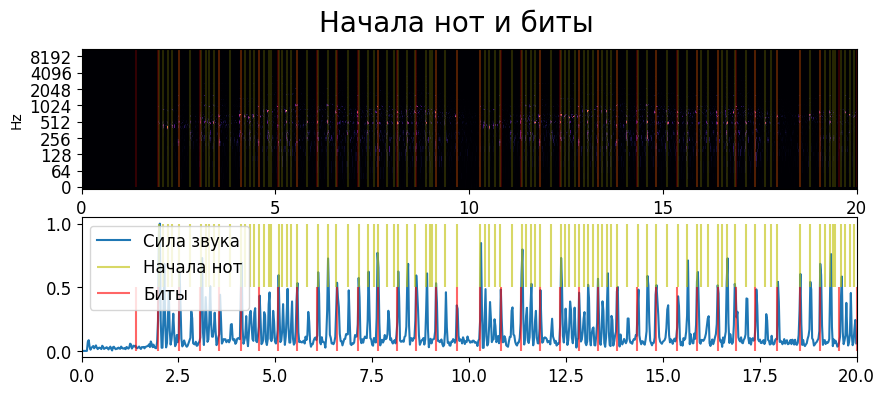

In [14]:
import matplotlib.pyplot as plt

times = librosa.times_like(oenv, sr=SR, hop_length=hop_length)
oenv2 = librosa.onset.onset_strength(y=y, sr=SR, hop_length=hop_length)
oenv2 /= oenv2.max()

fig, [ax0, ax1] = plt.subplots(2, 1, figsize=(10, 4))
fig.suptitle('Начала нот и биты', fontsize=20)

librosa.display.specshow(diff_D, sr=SR, x_axis='time', y_axis='log', n_fft=n_fft, hop_length=hop_length,
                         ax=ax0)
ax0.vlines(onset_times, 0, SR / 2, color='y', label='Onsets', alpha = 0.2)
ax0.vlines(beat_times, 0, SR / 2, color='r', label='Beats', alpha = 0.2)

ax1.plot(times, oenv2, label='Сила звука')
ax1.vlines(onset_times, oenv.max() / 2, oenv.max(), color='y', alpha=0.6, label='Начала нот')
ax1.vlines(beat_times, 0, oenv.max() / 2, color='r', alpha=0.6, label='Биты')
ax1.legend(fontsize=12)

for ax in [ax0, ax1]:
    ax.tick_params(labelsize=12)
    ax.set_xlim(0, 20)
fig.show()

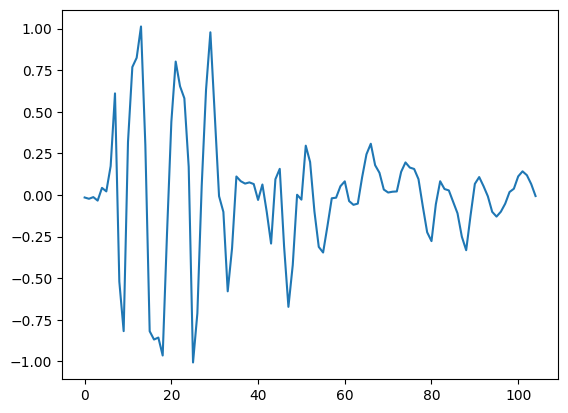

In [15]:
from IPython.display import Audio
from matplotlib import pyplot as plt

y_copy = y.copy()
click_sound, _ = librosa.load('audio_folder/mixkit-on-or-off-light-switch-tap-2585.wav', sr=SR)
click_sound = click_sound[20:125]
plt.plot(click_sound)
coeff = 1
click_sound *= (y.max() - y.min()) / coeff / (click_sound.max() - click_sound.min())
n = click_sound.shape[0]
shift = 20
for b in librosa.frames_to_samples(beat_frames, hop_length=HOP_LENGTH):
    x1 = max(b+shift-n, 0)
    x2 = min(b+shift, y.shape[0])
    if x2 > x1:
        y_copy[x1:x2] += click_sound[:x2-x1] * 1
for b in librosa.frames_to_samples(onset_frames, hop_length=HOP_LENGTH):
    x1 = max(b+shift-n, 0)
    x2 = min(b+shift, y.shape[0])
    if x2 > x1:
        y_copy[x1:x2] += click_sound[:x2-x1] * 0.5
Audio(y_copy, rate=SR)

# Анализ дифф спектрограммы

## View CQT

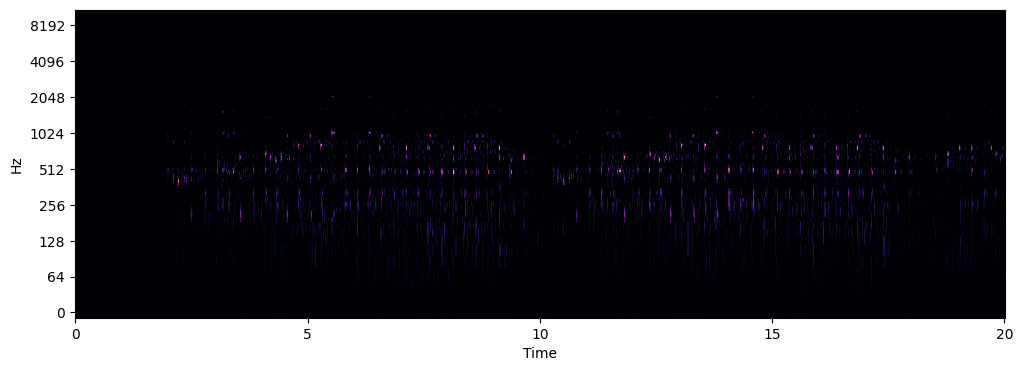

In [16]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(diff_D, sr=SR, x_axis='time', y_axis='log', n_fft=n_fft, hop_length=hop_length)
plt.show()

In [17]:
fmin = NOTE_A_MIN

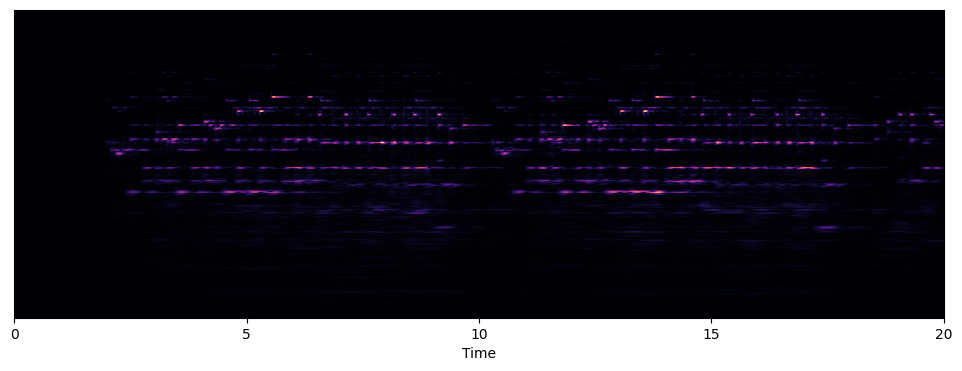

In [18]:
cqt = np.abs(librosa.cqt(y, sr=SR, fmin=fmin, n_bins=N_BINS, bins_per_octave=BINS_PER_OCT,
                         hop_length=hop_length))
plt.figure(figsize=(12, 4))
librosa.display.specshow(cqt[:], sr=SR, x_axis='time')
plt.plot()
plt.show()

## Analyse current

In [19]:
onset_frames

array([ 85,  90,  95, 100, 107, 120, 132, 137, 141, 146, 152, 164, 176,
       181, 186, 191, 196, 202, 207, 210, 218, 222, 227, 232, 238, 250,
       262, 273, 282, 295, 307, 317, 324, 328, 339, 346, 351, 361, 370,
       382, 386, 389, 393, 403, 416, 442, 447, 452, 458, 464, 477, 488,
       493, 498, 503, 508, 521, 532, 536, 541, 547, 552, 557, 562, 567,
       573, 578, 583, 588, 594, 605, 617, 628, 637, 650, 662, 672, 683,
       687, 695, 706, 711, 716, 725, 737, 748, 759, 765, 772, 797, 809,
       820, 825, 831, 834, 836, 843, 848, 853, 858])

In [20]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ""

In [21]:
from tf_keras import models

I0000 00:00:1778867830.724652   14871 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778867830.760229   14871 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778867832.125180   14871 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [22]:
from modules.help_funcs import get_X_data

In [23]:
cqt_T = cqt.T
cqt_T = np.concat([np.zeros((DELTA_PRED, cqt_T.shape[1])), cqt_T, np.zeros((DELTA_POST + 1, cqt_T.shape[1]))])
diff_cqt = np.maximum(0, np.diff(cqt_T, axis=0))

cqt_onsets = np.array([diff_cqt[ons : ons + DELTA_PRED + DELTA_POST + 1] for ons in onset_frames])
X = get_X_data(cqt_onsets)

In [24]:
model = models.load_model(m_path)
all_note_onsets = model.predict(X) > threshold

E0000 00:00:1778867832.878540   14871 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


4/4 [==============================] - 0s 1ms/step


In [25]:
onset_frames

array([ 85,  90,  95, 100, 107, 120, 132, 137, 141, 146, 152, 164, 176,
       181, 186, 191, 196, 202, 207, 210, 218, 222, 227, 232, 238, 250,
       262, 273, 282, 295, 307, 317, 324, 328, 339, 346, 351, 361, 370,
       382, 386, 389, 393, 403, 416, 442, 447, 452, 458, 464, 477, 488,
       493, 498, 503, 508, 521, 532, 536, 541, 547, 552, 557, 562, 567,
       573, 578, 583, 588, 594, 605, 617, 628, 637, 650, 662, 672, 683,
       687, 695, 706, 711, 716, 725, 737, 748, 759, 765, 772, 797, 809,
       820, 825, 831, 834, 836, 843, 848, 853, 858])

107


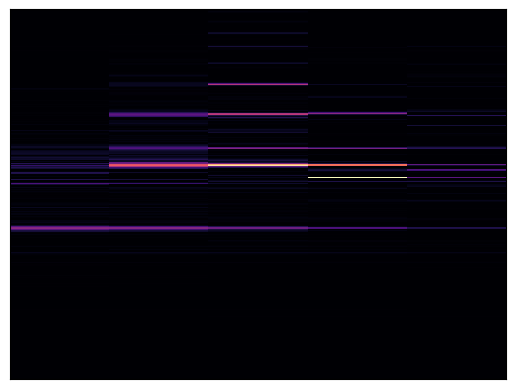

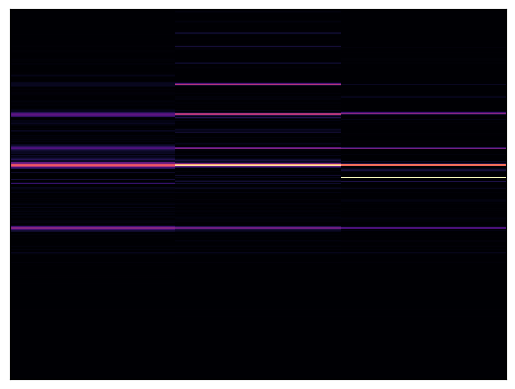

In [26]:
idx = 4

ons = onset_frames[idx]
print(ons)
librosa.display.specshow(diff_cqt[ons - 1: ons + DELTA_POST + DELTA_PRED + 2].T)
plt.show()

librosa.display.specshow(cqt_onsets[idx].T)
plt.show()

In [27]:
from modules.rhythm_extract import match_onsets_to_beats
ons_idxs, durations, time_signature = match_onsets_to_beats(
    onset_frames, beat_frames, mult_coeff, onset_strength=oenv, size_hint=None
)

In [28]:
print(ons_idxs, durations, time_signature)

[  4   5   6   7   8  10  12  13  14  15  16  18  20  21  22  23  24  25
  26  27  28  29  30  31  32  34  36  38  40  42  44  46  47  48  50  51
  52  54  56  58  59  59  60  62  64  68  69  70  71  72  74  76  77  78
  79  80  82  84  85  86  87  88  89  90  91  92  93  94  95  96  98 100
 102 104 106 108 110 112 113 114 116 117 118 120 122 124 126 127 128 132
 134 136 137 138 139 139 140 141 142 143] [0.25 0.25 0.25 0.25 0.5  0.5  0.25 0.25 0.25 0.25 0.5  0.5  0.25 0.25
 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.5  0.5  0.5  0.5
 0.5  0.5  0.5  0.25 0.25 0.5  0.25 0.25 0.5  0.5  0.5  0.25 0.   0.25
 0.5  0.5  1.   0.25 0.25 0.25 0.25 0.5  0.5  0.25 0.25 0.25 0.25 0.5
 0.5  0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.5
 0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.25 0.25 0.5  0.25 0.25 0.5  0.5
 0.5  0.5  0.25 0.25 1.   0.5  0.5  0.25 0.25 0.25 0.   0.25 0.25 0.25
 0.25 0.25] 2/4


# Piano roll to MusicXML

In [29]:
from modules.get_musicxml import *

In [30]:
piano_notes = modify_piano_notes(all_note_onsets)
score, key = piano_notes_to_mxml(piano_notes, ons_idxs / mult_coeff, durations, time_signature)
score, _ = piano_notes_to_mxml(piano_notes, ons_idxs / mult_coeff, durations, time_signature, key_signature=key)

score.write('musicxml', fp=f'musicxml_folder/{file_name}.musicxml')

A minor
A minor


PosixPath('/home/julia/Music/diploma/Rhythm_first_AMT/musicxml_folder/turkish-march-mozart-rondo-alla-turca.musicxml')

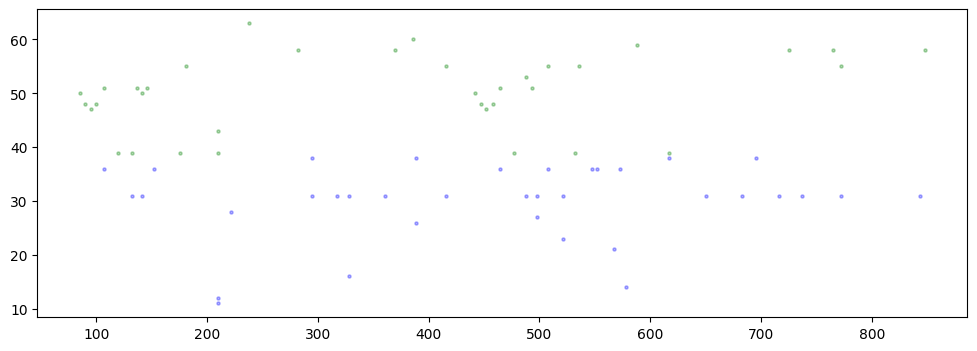

In [31]:
plt.figure(figsize=(12, 4))
for idx, ons in enumerate(onset_frames):
    notes_left = np.arange(88)[piano_notes[idx] == 1]
    notes_right = np.arange(88)[piano_notes[idx] == 2]
    onset_left_arr = np.ones_like(notes_left) * ons
    onset_right_arr = np.ones_like(notes_right) * ons
    plt.scatter(onset_left_arr, notes_left, s=5, alpha=0.3, color='blue')
    plt.scatter(onset_right_arr, notes_right, s=5, alpha=0.3, color='green')
plt.show()